# งานที่ 1: ทำนายการได้งานของนักศึกษา (Campus Recruitment)
เปรียบเทียบ 3 โมเดล: **Logistic Regression, Random Forest, SVM**
ด้วยตัวชี้วัด **Accuracy, Precision, Recall, F1-Score**

**วิธีใช้ (VS Code):** วางไฟล์ `Placement_Data_Full_Class.csv` ไว้โฟลเดอร์เดียวกับไฟล์นี้ เลือก kernel `ml-env` แล้วกด **Run All**

## ขั้นที่ 0: ตรวจว่ามีไฟล์ข้อมูล
ไฟล์ `Placement_Data_Full_Class.csv` ต้องอยู่โฟลเดอร์เดียวกับ Notebook นี้

In [2]:
import os
print("โฟลเดอร์ที่ทำงานอยู่:", os.getcwd())
print("เจอไฟล์ CSV ไหม:", os.path.exists("Placement_Data_Full_Class.csv"))

โฟลเดอร์ที่ทำงานอยู่: d:\project_Ai
เจอไฟล์ CSV ไหม: True


## ขั้นที่ 1: โหลดและสำรวจข้อมูล

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Placement_Data_Full_Class.csv")

print("ขนาดข้อมูล (แถว, คอลัมน์):", df.shape)
print("\nจำนวนค่าว่างในแต่ละคอลัมน์:")
print(df.isnull().sum())
print("\nสัดส่วนได้งาน / ไม่ได้งาน:")
print(df["status"].value_counts())
df.head()

ขนาดข้อมูล (แถว, คอลัมน์): (215, 15)

จำนวนค่าว่างในแต่ละคอลัมน์:
sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

สัดส่วนได้งาน / ไม่ได้งาน:
status
Placed        148
Not Placed     67
Name: count, dtype: int64


,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


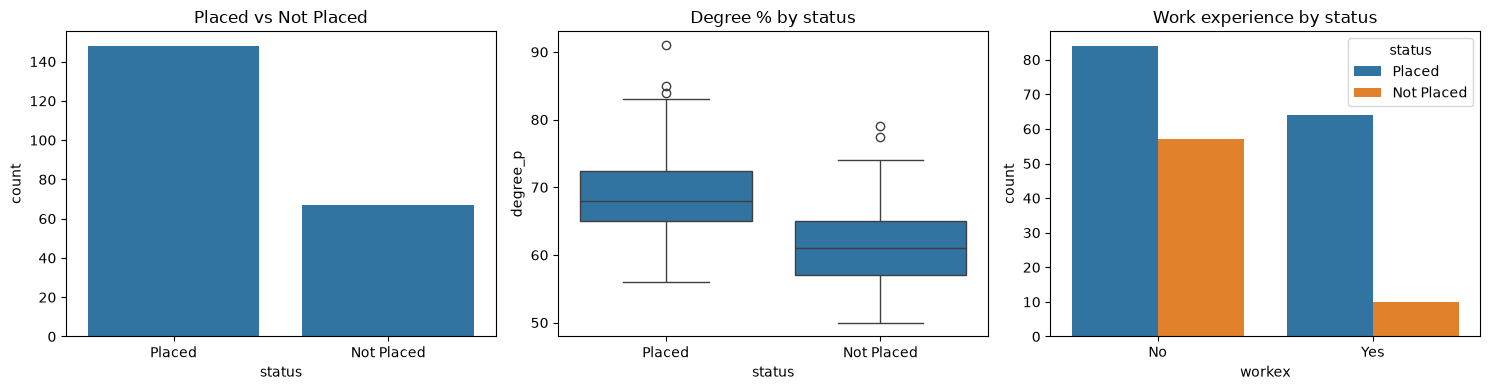

In [4]:
# กราฟ: สัดส่วนได้งาน และเกรดเทียบกับผลการได้งาน
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(data=df, x="status", ax=axes[0])
axes[0].set_title("Placed vs Not Placed")
sns.boxplot(data=df, x="status", y="degree_p", ax=axes[1])
axes[1].set_title("Degree % by status")
sns.countplot(data=df, x="workex", hue="status", ax=axes[2])
axes[2].set_title("Work experience by status")
plt.tight_layout()
plt.show()

## ขั้นที่ 2: เตรียมข้อมูล
- ตัด `sl_no` (เลขลำดับ ไม่มีความหมาย)
- ตัด `salary` เพราะคนไม่ได้งานไม่มีเงินเดือน ถ้าเก็บไว้โมเดลจะแอบเห็นเฉลย (**data leakage**)
- แปลงเป้าหมาย: Placed = 1, Not Placed = 0
- แปลงคอลัมน์ตัวอักษรเป็นคอลัมน์ 0/1 (**One-Hot Encoding**)

In [5]:
data = df.drop(columns=["sl_no", "salary"])
data["status"] = data["status"].map({"Placed": 1, "Not Placed": 0})

y = data["status"]
X = pd.get_dummies(data.drop(columns="status"), drop_first=True, dtype=int)

print("ขนาดฟีเจอร์:", X.shape)
print("ฟีเจอร์ที่ใช้:", X.columns.tolist())
X.head()

ขนาดฟีเจอร์: (215, 14)
ฟีเจอร์ที่ใช้: ['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p', 'gender_M', 'ssc_b_Others', 'hsc_b_Others', 'hsc_s_Commerce', 'hsc_s_Science', 'degree_t_Others', 'degree_t_Sci&Tech', 'workex_Yes', 'specialisation_Mkt&HR']


,ssc_p,hsc_p,degree_p,etest_p,mba_p,gender_M,ssc_b_Others,hsc_b_Others,hsc_s_Commerce,hsc_s_Science,degree_t_Others,degree_t_Sci&Tech,workex_Yes,specialisation_Mkt&HR
0,67.00,91.00,58.00,55.0,58.80,1,1,1,1,0,0,1,0,1
1,79.33,78.33,77.48,86.5,66.28,1,0,1,0,1,0,1,1,0
2,65.00,68.00,64.00,75.0,57.80,1,0,0,0,0,0,0,0,0
3,56.00,52.00,52.00,66.0,59.43,1,0,0,0,1,0,1,0,1
4,85.80,73.60,73.30,96.8,55.50,1,0,0,1,0,0,0,0,0


## ขั้นที่ 3: แบ่งข้อมูล train/test (80/20) และปรับสเกล
- `stratify=y` ให้สัดส่วนได้งาน/ไม่ได้งานในสองชุดเท่ากัน
- `random_state=42` ให้รันซ้ำแล้วผลเหมือนเดิม
- ปรับสเกลด้วย StandardScaler โดย fit จาก train เท่านั้น

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("train:", len(X_train), "แถว | test:", len(X_test), "แถว")

train: 172 แถว | test: 43 แถว


## ขั้นที่ 4: เทรน 3 โมเดล และเปรียบเทียบตัวชี้วัด

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": SVC(kernel="rbf", random_state=42),
}

results = []
predictions = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    predictions[name] = y_pred
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
    })

results_df = pd.DataFrame(results).set_index("Model").round(4)
results_df

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,0.8605,0.9286,0.8667,0.8966
Random Forest,0.8372,0.8485,0.9333,0.8889
SVM,0.8372,0.9259,0.8333,0.8772


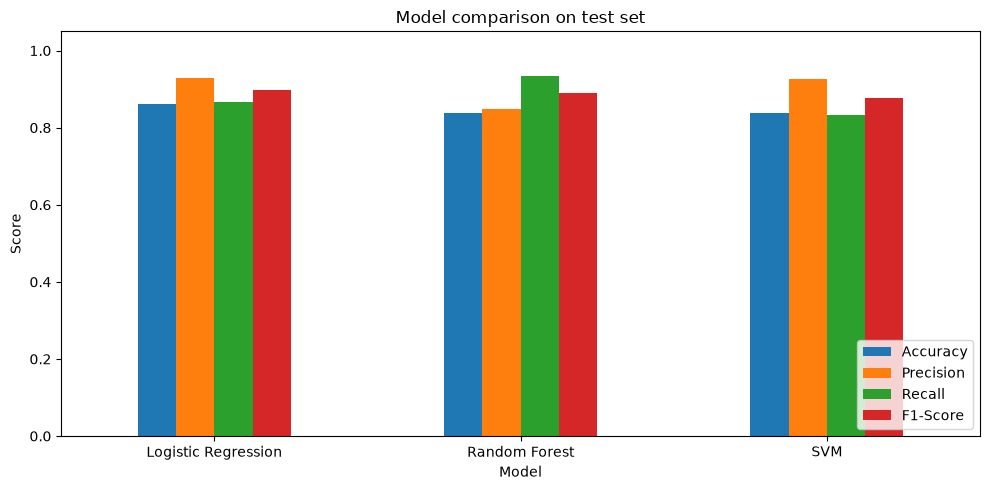

In [8]:
# กราฟแท่งเปรียบเทียบตัวชี้วัด
results_df.plot(kind="bar", figsize=(10, 5), ylim=(0, 1.05), rot=0)
plt.title("Model comparison on test set")
plt.ylabel("Score")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## ขั้นที่ 5: Confusion Matrix
ดูว่าแต่ละโมเดลทายถูก/ผิดแบบไหน (แถว = ค่าจริง, คอลัมน์ = ค่าที่ทาย)

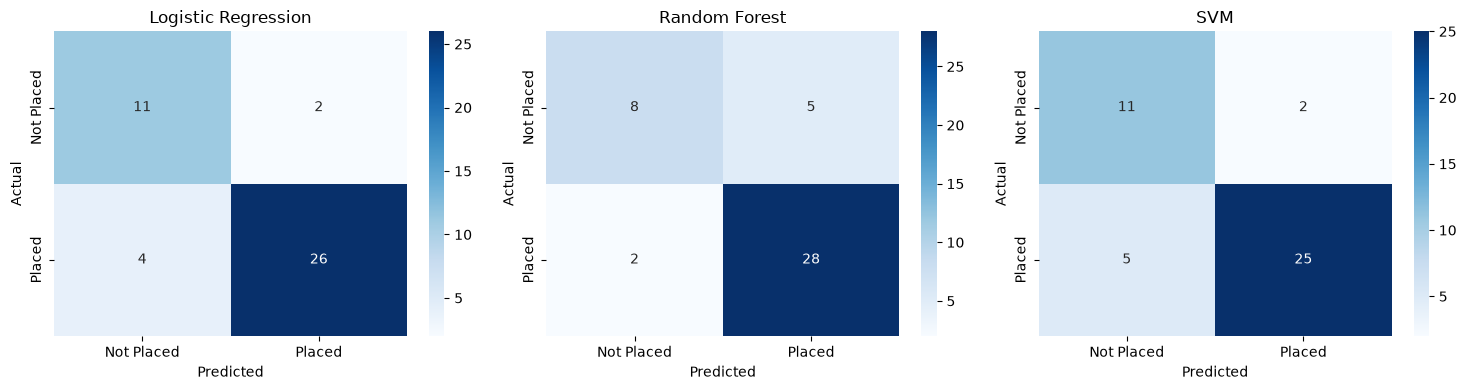

In [9]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Not Placed", "Placed"],
                yticklabels=["Not Placed", "Placed"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

## ขั้นที่ 6: Cross-Validation (5-fold)
ชุด test มีแค่ 43 แถว ผลอาจแกว่งตามการสุ่ม จึงทดสอบซ้ำ 5 รอบเพื่อยืนยันผล
(ใช้ Pipeline เพื่อให้ปรับสเกลแยกในแต่ละรอบ ไม่รั่วข้อมูล)

In [10]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.pipeline import make_pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["accuracy", "precision", "recall", "f1"]

cv_results = []
for name, model in models.items():
    pipe = make_pipeline(StandardScaler(), model)
    scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring)
    row = {"Model": name}
    for s in scoring:
        row[s.capitalize() + " (mean)"] = scores["test_" + s].mean()
        row[s.capitalize() + " (std)"] = scores["test_" + s].std()
    cv_results.append(row)

cv_df = pd.DataFrame(cv_results).set_index("Model").round(4)
cv_df

,Accuracy (mean),Accuracy (std),Precision (mean),Precision (std),Recall (mean),Recall (std),F1 (mean),F1 (std)
Model,,,,,,,,
Logistic Regression,0.8651,0.0400,0.8852,0.0418,0.9257,0.0253,0.9045,0.0277
Random Forest,0.8605,0.0510,0.8641,0.0318,0.9460,0.0459,0.9030,0.0362
SVM,0.8605,0.0208,0.8652,0.0174,0.9464,0.0541,0.9027,0.0173


## ขั้นที่ 7: ปัจจัยไหนสำคัญที่สุด (Feature Importance จาก Random Forest)

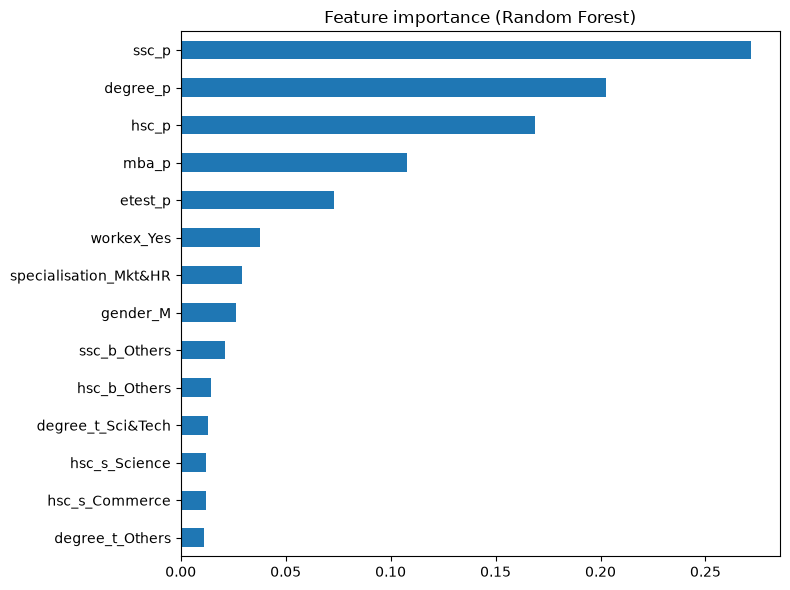

5 ปัจจัยที่สำคัญที่สุด:
ssc_p       0.2719
degree_p    0.2025
hsc_p       0.1686
mba_p       0.1079
etest_p     0.0730
dtype: float64


In [11]:
importances = pd.Series(
    models["Random Forest"].feature_importances_, index=X.columns
).sort_values()

importances.plot(kind="barh", figsize=(8, 6))
plt.title("Feature importance (Random Forest)")
plt.tight_layout()
plt.show()

print("5 ปัจจัยที่สำคัญที่สุด:")
print(importances.sort_values(ascending=False).head(5).round(4))

       improvement  uni_avg
count       215.00   215.00
mean         -0.93    64.32
std           9.25     5.54
min         -22.33    52.48
25%          -6.83    60.52
50%          -0.90    64.04
75%           4.80    67.37
max          33.00    80.35


Accuracy                                     F1  \
แบบ                 A ทุกตัวแปร B ไม่ใช้มัธยม C ตัวแปรใหม่ A ทุกตัวแปร   
Model                                                                    
Logistic Regression      0.8651        0.8233       0.8744      0.9045   
Random Forest            0.8605        0.8000       0.8605      0.9030   
SVM                      0.8605        0.7721       0.8512      0.9027   

                                                
แบบ                 B ไม่ใช้มัธยม C ตัวแปรใหม่  
Model                                           
Logistic Regression        0.8790       0.9106  
Random Forest              0.8619       0.9035  
SVM                        0.8442       0.8965

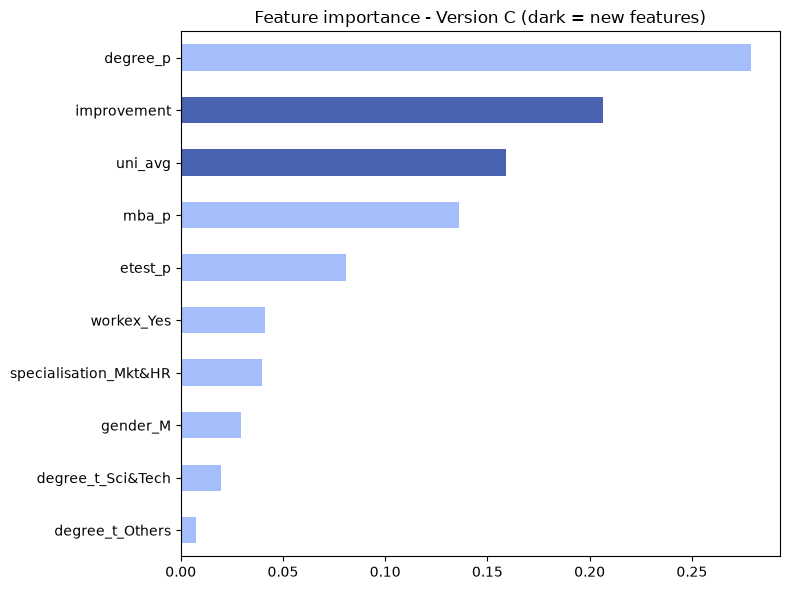

degree_p       0.2791
improvement    0.2066
uni_avg        0.1592
mba_p          0.1361
etest_p        0.0810
dtype: float64


In [12]:
# ===== Feature Engineering: สร้างตัวแปรใหม่ แล้วเทียบ 3 แบบ =====
# 1) สร้างตัวแปรใหม่จากข้อมูลเดิม
fe = pd.DataFrame(index=X.index)
fe["improvement"] = df["degree_p"] - df["ssc_p"]        # พัฒนาการ: ปริญญาตรี - มัธยมต้น
fe["uni_avg"] = (df["degree_p"] + df["mba_p"]) / 2      # เฉลี่ยระดับมหาวิทยาลัย
print(fe.describe().round(2))

# 2) เตรียมข้อมูล 3 แบบ
school_cols = [c for c in X.columns if c.startswith(("ssc_", "hsc_"))]
X_A = X                                                  # A: ทุกตัวแปร (แบบเดิม)
X_B = X.drop(columns=school_cols)                        # B: ไม่ใช้ข้อมูลมัธยม
X_C = pd.concat([X_B, fe], axis=1)                       # C: B + ตัวแปรใหม่
versions = {"A ทุกตัวแปร": X_A, "B ไม่ใช้มัธยม": X_B, "C ตัวแปรใหม่": X_C}

# 3) เทียบด้วย Cross-Validation 5 รอบ
rows = []
for name, model in models.items():
    for label, data in versions.items():
        pipe = make_pipeline(StandardScaler(), model)
        s = cross_validate(pipe, data, y, cv=cv, scoring=["accuracy", "f1"])
        rows.append({"Model": name, "แบบ": label,
                     "Accuracy": s["test_accuracy"].mean(), "F1": s["test_f1"].mean()})
fe_results = pd.DataFrame(rows).pivot(index="Model", columns="แบบ").round(4)
display(fe_results)

# 4) ความสำคัญของตัวแปรในแบบ C
from sklearn.ensemble import RandomForestClassifier
rf_c = RandomForestClassifier(n_estimators=200, random_state=42).fit(X_C, y)
imp_c = pd.Series(rf_c.feature_importances_, index=X_C.columns).sort_values()
imp_c.plot(kind="barh", figsize=(8, 6), color=["#4A63B0" if c in fe.columns else "#A3BEFA" for c in imp_c.index])
plt.title("Feature importance - Version C (dark = new features)")
plt.tight_layout(); plt.show()
print(imp_c.sort_values(ascending=False).head(5).round(4))

## ขั้นที่ 8: สรุปผล (กลุ่มเติมเองหลังรัน)
- โมเดลที่ดีที่สุดคือ ............ เพราะ ............
- ปัจจัยที่มีผลต่อการได้งานมากที่สุดคือ ............
- ข้อจำกัด: ข้อมูลมีเพียง 215 แถว มาจากสถาบันในอินเดีย ไม่มีปัจจัยอื่น เช่น ทักษะการสัมภาษณ์ จึงใช้เพื่อการศึกษาเท่านั้น